Loading: /home/rbielski/SOOP/ds004889/sub-1/anat/sub-1_T1w.nii.gz
Volume shape: (512, 512, 26)
Extracting Gaussians ...
Gaussians: 37029 | sigma(world)=1.7246
Rendering projection ...


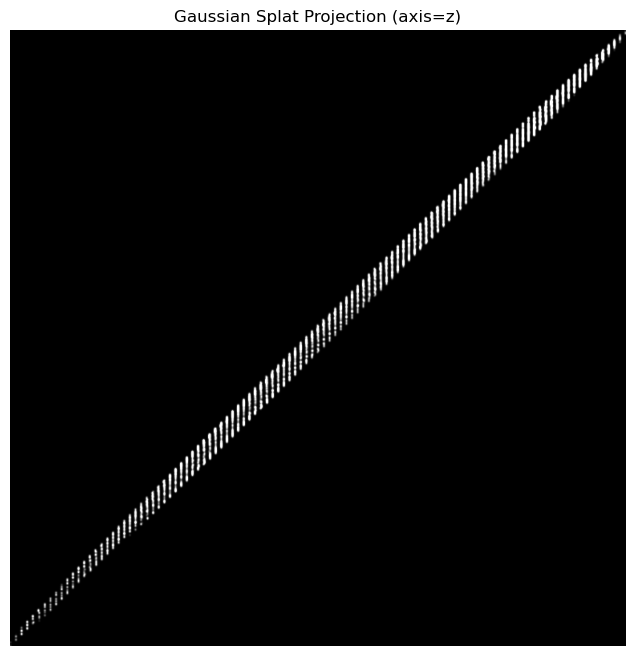

In [1]:
# %% [markdown]
# ### Gaussian Splatting for a 3D MRI — all-in-one notebook cell
# - Paste this entire block into **one** cell in your .ipynb and run it.
# - Set `INPUT_PATH` to your NIfTI file (T1w, etc.).
# - Adjust `THRESHOLD`, `SUBSAMPLE`, and `SIGMA_VOX` for quality vs. speed.
# - The code is CPU-only for clarity; I can refactor to PyTorch+CUDA if you want GPU.

# %%
import math
import sys
import subprocess
from dataclasses import dataclass
from typing import Optional, Tuple

# --- ensure deps ---
try:
    import numpy as np
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy"])
    import numpy as np

try:
    import nibabel as nib
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nibabel"])
    import nibabel as nib

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

# ------------------------------
# Parameters (edit these)
# ------------------------------
INPUT_PATH = "/home/rbielski/SOOP/ds004889/sub-1/anat/sub-1_T1w.nii.gz"  # e.g., 
# "/home/rbielski/SOOP/ds004889/sub-1/anat/sub-1_T1w.nii.gz"
THRESHOLD  = 0.10   # keep voxels with intensity >= THRESHOLD (0..1 after normalization)
SUBSAMPLE  = 4      # stride per axis (1 = dense; higher = faster, fewer splats)
SIGMA_VOX  = 0.75   # Gaussian std dev in *voxel* units (isotropic)
AXIS       = 'z'    # projection axis: 'x' | 'y' | 'z'
OUT_SIZE   = (768, 768)  # height, width of projection image
OPACITY    = 1.25   # scales contribution per splat (try 0.5–2.0)
MAX_POINTS = 500_000      # cap point count before rendering
MAX_RENDER = 300_000      # cap rendered points (random downsample)

# ------------------------------
# Core implementation
# ------------------------------
@dataclass
class GaussianSet:
    mu: np.ndarray  # (N,3) means in world coords
    sigma: float    # isotropic std dev in *world* units
    w: np.ndarray   # (N,) weights (e.g., normalized intensities)
    bounds: Optional[Tuple[Tuple[float, float, float], Tuple[float, float, float]]] = None


def _voxel_size_from_affine(affine: np.ndarray) -> Tuple[float, float, float]:
    A = affine[:3, :3]
    sx, sy, sz = np.linalg.norm(A[:, 0]), np.linalg.norm(A[:, 1]), np.linalg.norm(A[:, 2])
    return float(sx), float(sy), float(sz)


def _world_coords_from_indices(affine: np.ndarray, idx: np.ndarray) -> np.ndarray:
    N = idx.shape[0]
    homo = np.ones((N, 4), dtype=np.float32)
    homo[:, :3] = idx.astype(np.float32)
    world = (affine @ homo.T).T[:, :3]
    return world.astype(np.float32)


def load_nifti(path: str) -> Tuple[np.ndarray, np.ndarray]:
    img = nib.load(path)
    data = img.get_fdata(dtype=np.float32)
    affine = img.affine.astype(np.float32)

    finite = np.isfinite(data)
    if not np.any(finite):
        raise ValueError("Volume contains no finite values.")
    vmin, vmax = float(np.min(data[finite])), float(np.max(data[finite]))
    if vmax > vmin:
        data = (data - vmin) / (vmax - vmin)
    else:
        data = np.zeros_like(data, dtype=np.float32)
    return data.astype(np.float32), affine


def extract_gaussians(
    data: np.ndarray,
    affine: np.ndarray,
    intensity_threshold: float = 0.1,
    subsample: int = 4,
    sigma_vox: float = 0.75,
    max_points: int = 500_000,
) -> GaussianSet:
    if data.ndim != 3:
        raise ValueError("Expected a 3D volume.")

    mask = data >= float(intensity_threshold)
    zz, yy, xx = np.where(mask)

    if subsample > 1:
        sel = (xx % subsample == 0) & (yy % subsample == 0) & (zz % subsample == 0)
        xx, yy, zz = xx[sel], yy[sel], zz[sel]

    N = xx.size
    if N == 0:
        raise ValueError("No voxels passed the threshold; try lowering it.")

    if N > max_points:
        idx = np.random.choice(N, size=max_points, replace=False)
        xx, yy, zz = xx[idx], yy[idx], zz[idx]
        N = max_points

    idx_3d = np.stack([xx, yy, zz], axis=1)
    mu = _world_coords_from_indices(affine, idx_3d)

    sx, sy, sz = _voxel_size_from_affine(affine)
    sigma_world = float(sigma_vox * ((sx + sy + sz) / 3.0))

    w = data[zz, yy, xx].astype(np.float32)
    mins, maxs = mu.min(axis=0), mu.max(axis=0)
    return GaussianSet(mu=mu.astype(np.float32), sigma=sigma_world, w=w,
                       bounds=(tuple(mins), tuple(maxs)))


def render_projection(
    gset: GaussianSet,
    axis: str = "z",
    image_size: Tuple[int, int] = (512, 512),
    opacity_scale: float = 1.0,
    clamp: Tuple[float, float] = (0.0, 1.0),
    max_points_render: int = 300_000,
) -> np.ndarray:
    H, W = int(image_size[0]), int(image_size[1])
    mu, w = gset.mu, gset.w

    N = mu.shape[0]
    if N > max_points_render:
        keep = np.random.choice(N, size=max_points_render, replace=False)
        mu, w = mu[keep], w[keep]
        N = max_points_render

    # project by dropping one axis
    if axis.lower() == "z":
        pts2 = mu[:, [0, 1]]  # (x, y)
    elif axis.lower() == "y":
        pts2 = mu[:, [0, 2]]  # (x, z)
    elif axis.lower() == "x":
        pts2 = mu[:, [1, 2]]  # (y, z)
    else:
        raise ValueError("axis must be one of {'x','y','z'}")

    # normalize to [0,1] using bounds
    if gset.bounds is None:
        mins, maxs = pts2.min(axis=0), pts2.max(axis=0)
    else:
        mins = np.array(gset.bounds[0][:2], dtype=np.float32)
        maxs = np.array(gset.bounds[1][:2], dtype=np.float32)
    span = np.maximum(maxs - mins, 1e-6)
    uv = (pts2 - mins) / span

    # pixel coords (flip y for image convention)
    px = np.clip((uv[:, 0] * (W - 1)).round().astype(np.int32), 0, W - 1)
    py = np.clip(((1.0 - uv[:, 1]) * (H - 1)).round().astype(np.int32), 0, H - 1)

    # convert world sigma to pixels using average scale of bounds
    avg_world_span = float((span[0] + span[1]) / 2.0)
    sigma_px = max(0.5, (gset.sigma / max(avg_world_span, 1e-6)) * ((W + H) * 0.5))
    r = int(max(1, math.ceil(3.0 * sigma_px)))

    # precompute 2D Gaussian kernel
    yy, xx = np.mgrid[-r:r + 1, -r:r + 1]
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_px**2)).astype(np.float32)
    kernel /= (2.0 * math.pi * sigma_px**2)  # normalized pdf

    canvas = np.zeros((H, W), dtype=np.float32)

    # accumulate splats
    for (ix, iy, wt) in zip(px, py, w):
        if wt <= 0:
            continue
        x0, x1 = max(0, ix - r), min(W, ix + r + 1)
        y0, y1 = max(0, iy - r), min(H, iy + r + 1)
        kx0, kx1 = x0 - (ix - r), kernel.shape[1] - ((ix + r + 1) - x1)
        ky0, ky1 = y0 - (iy - r), kernel.shape[0] - ((iy + r + 1) - y1)
        canvas[y0:y1, x0:x1] += opacity_scale * wt * kernel[ky0:ky1, kx0:kx1]

    lo, hi = clamp
    canvas = np.clip(canvas, lo, hi)
    if hi > 1.0:
        canvas = (canvas - lo) / (hi - lo + 1e-6)
    return canvas.astype(np.float32)

# ------------------------------
# Run pipeline
# ------------------------------
print("Loading:", INPUT_PATH)
vol, aff = load_nifti(INPUT_PATH)
print("Volume shape:", vol.shape)
print("Extracting Gaussians ...")
G = extract_gaussians(vol, aff,
                     intensity_threshold=THRESHOLD,
                     subsample=SUBSAMPLE,
                     sigma_vox=SIGMA_VOX,
                     max_points=MAX_POINTS)
print(f"Gaussians: {G.mu.shape[0]} | sigma(world)={G.sigma:.4f}")

print("Rendering projection ...")
img = render_projection(G,
                        axis=AXIS,
                        image_size=OUT_SIZE,
                        opacity_scale=OPACITY,
                        max_points_render=MAX_RENDER)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.title(f"Gaussian Splat Projection (axis={AXIS})")
plt.axis('off')
plt.show()

# (Optional) save output
# plt.imsave("gaussian_splat_projection.png", img, cmap="gray")


In [14]:
# %% [markdown]
# ### MRI — Fix 4D/3D Mismatch + Resample (Single Cell)
# Your volume is 4D with a singleton 4th dim `(256, 256, 26, 1)`, while the mask is 3D `(256, 256, 26)`.
# This cell squeezes the volume to 3D, then **resamples the mask** onto the volume grid (NN), and saves outputs.
# Run this **before** the overlay/renderer cells.

# %%
import os, sys, subprocess

try:
    import numpy as np
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy'])
    import numpy as np

try:
    import nibabel as nib
    from nibabel.processing import resample_from_to
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nibabel'])
    import nibabel as nib
    from nibabel.processing import resample_from_to

# ------------------
# 🔧 Set your paths (edit if needed)
# ------------------
VOL_PATH  = "/home/rbielski/SOOP/ds004889/sub-1/dwi/sub-1_rec-TRACE_dwi.nii.gz"
MASK_PATH = "/home/rbielski/SOOP/ds004889/derivatives/lesion_masks/sub-1/dwi/sub-1_space-TRACE_desc-lesion_mask.nii.gz"

# ------------------
# Load images
# ------------------
vol_img = nib.load(VOL_PATH)
mask_img = nib.load(MASK_PATH)
vol_data = vol_img.get_fdata(dtype=np.float32)
mask_data = mask_img.get_fdata()

print("Original volume shape:", vol_data.shape)
print("Original mask   shape:", mask_data.shape)

# ------------------
# Squeeze 4D volume -> 3D if last dim==1
# ------------------
if vol_data.ndim == 4 and vol_data.shape[-1] == 1:
    vol_data_3d = np.ascontiguousarray(vol_data[..., 0])
    vol_img_3d = nib.Nifti1Image(vol_data_3d, vol_img.affine, vol_img.header)
    # fix header to 3D zooms if needed
    zooms = vol_img.header.get_zooms()
    if len(zooms) == 4:
        vol_img_3d.header.set_zooms(zooms[:3])
    print("Squeezed volume to 3D:", vol_img_3d.shape)
else:
    vol_img_3d = vol_img if vol_img.ndim == 3 else nib.Nifti1Image(np.squeeze(vol_data), vol_img.affine, vol_img.header)
    print("Volume already 3D:", vol_img_3d.shape)

# ------------------
# If mask is not integer, round to int labels
# ------------------
if mask_data.dtype.kind != 'i':
    mask_data = np.rint(mask_data).astype(np.int16)
mask_img_int = nib.Nifti1Image(mask_data, mask_img.affine, mask_img.header)

# ------------------
# Resample mask -> volume grid (3D -> 3D), NN to preserve labels
# ------------------
print("Resampling mask to squeezed volume grid ...")
img_m_rs = resample_from_to(mask_img_int, (vol_img_3d.shape, vol_img_3d.affine), order=0)

# ------------------
# Save outputs
# ------------------
# Save squeezed 3D volume next to original
vol_base, vol_ext = os.path.splitext(VOL_PATH)
if vol_ext == '.gz':
    vol_base, ext2 = os.path.splitext(vol_base)
    vol_ext = ext2 + '.gz'
vol_out = vol_base + "_squeezed3D" + vol_ext
nib.save(vol_img_3d, vol_out)

# Save resampled mask
mask_base, mask_ext = os.path.splitext(MASK_PATH)
if mask_ext == '.gz':
    mask_base, ext2 = os.path.splitext(mask_base)
    mask_ext = ext2 + '.gz'
mask_out = mask_base + "_resampToVOL3D" + mask_ext
nib.save(img_m_rs, mask_out)

print("\nSaved 3D volume:", vol_out)
print("Saved resampled mask:", mask_out)
print("\nFinal shapes:")
print("Vol 3D:", vol_img_3d.shape)
print("MaskRS:", img_m_rs.shape)

# ------------------
# Quick sanity: show unique labels of resampled mask
# ------------------
labels = np.unique(img_m_rs.get_fdata())
print("Resampled mask labels:", labels)

print("\n➡ Now use:")
print("VOL_PATH  =", vol_out)
print("MASK_PATH =", mask_out)
print("in the overlay/renderer cell.")


Original volume shape: (256, 256, 26, 1)
Original mask   shape: (256, 256, 26)
Squeezed volume to 3D: (256, 256, 26)
Resampling mask to squeezed volume grid ...

Saved 3D volume: /home/rbielski/SOOP/ds004889/sub-1/dwi/sub-1_rec-TRACE_dwi_squeezed3D.nii.gz
Saved resampled mask: /home/rbielski/SOOP/ds004889/derivatives/lesion_masks/sub-1/dwi/sub-1_space-TRACE_desc-lesion_mask_resampToVOL3D.nii.gz

Final shapes:
Vol 3D: (256, 256, 26)
MaskRS: (256, 256, 26)
Resampled mask labels: [0. 1.]

➡ Now use:
VOL_PATH  = /home/rbielski/SOOP/ds004889/sub-1/dwi/sub-1_rec-TRACE_dwi_squeezed3D.nii.gz
MASK_PATH = /home/rbielski/SOOP/ds004889/derivatives/lesion_masks/sub-1/dwi/sub-1_space-TRACE_desc-lesion_mask_resampToVOL3D.nii.gz
in the overlay/renderer cell.


Volume shape: (256, 256, 26) | min=0.0000 max=1.0000 var=0.002263
Mask labels: [0 1]


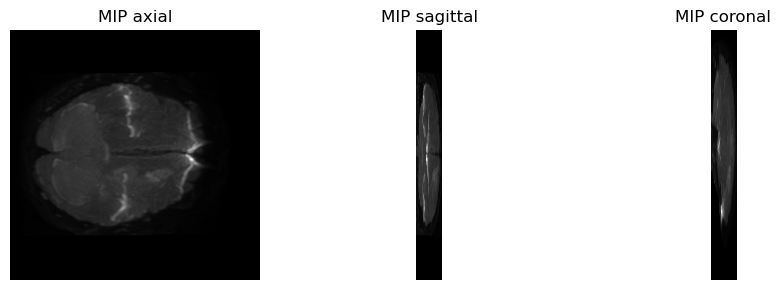

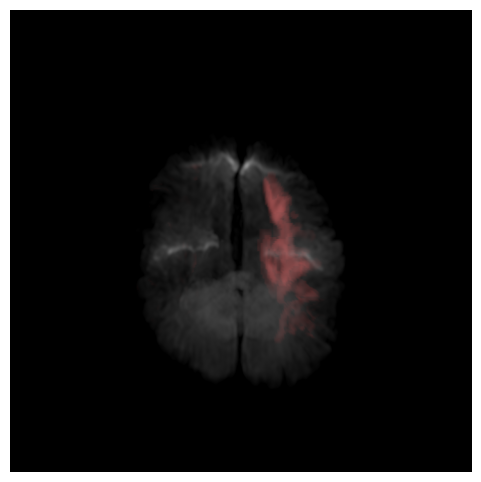

In [32]:
# %% [markdown]
# # MRI 3D — Robust AABB Raymarch (Fix Black Screen)
# This version **guarantees we march inside the volume** by intersecting each ray with
# the unit cube [0,1]^3 (Axis-Aligned Bounding Box). That fixes the "all‑black" view
# caused by rays missing the data bounds. Also includes a quick 2D MIP check.
#
# 👉 Set VOL_PATH / MASK_PATH below (mask optional), run the single cell.

# %%
import os, math, sys, subprocess

# deps
try:
    import numpy as np
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy'])
    import numpy as np

try:
    import torch
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch'])
    import torch

try:
    import nibabel as nib
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nibabel'])
    import nibabel as nib

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])
    import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipywidgets'])
    import ipywidgets as widgets
    from IPython.display import display, clear_output

# -------------------------------
# 🔧 Paths (edit)
# -------------------------------
VOL_PATH  = "/home/rbielski/SOOP/ds004889/sub-1/dwi/sub-1_rec-TRACE_dwi.nii.gz"
MASK_PATH = "/home/rbielski/SOOP/ds004889/derivatives/lesion_masks/sub-1/dwi/sub-1_space-TRACE_desc-lesion_mask.nii.gz"  # or None
RES_HW    = (720, 720)
STEPS_DEF = 256

LABEL_COLORS = {0:(0,0,0,0), 1:(1,0.2,0.2,0.7)}

# -------------------------------
# Load + normalize + squeeze 4D→3D if needed
# -------------------------------
img = nib.load(VOL_PATH); vol_np = img.get_fdata(dtype=np.float32)
if vol_np.ndim == 4 and vol_np.shape[-1] == 1:
    vol_np = vol_np[...,0]
finite = np.isfinite(vol_np)
if not finite.any():
    raise ValueError("Volume has no finite values.")
lo, hi = float(vol_np[finite].min()), float(vol_np[finite].max())
vol_np = (vol_np - lo) / (hi - lo + 1e-8)
vol_np = np.clip(vol_np, 0, 1)
print(f"Volume shape: {vol_np.shape} | min={vol_np.min():.4f} max={vol_np.max():.4f} var={vol_np.var():.4g}")

mask_np = None
if MASK_PATH and os.path.exists(MASK_PATH):
    mimg = nib.load(MASK_PATH); mask_np = mimg.get_fdata()
    if mask_np.ndim == 4 and mask_np.shape[-1] == 1:
        mask_np = mask_np[...,0]
    if mask_np.dtype.kind != 'i':
        mask_np = np.rint(mask_np).astype(np.int16)
    if mask_np.shape != vol_np.shape:
        print("WARNING: mask/volume shapes differ; proceeding without mask overlay.")
        mask_np = None
    else:
        print("Mask labels:", np.unique(mask_np))

# -------------------------------
# Quick sanity: show central MIP (should not be black)
# -------------------------------
fig, ax = plt.subplots(1,3, figsize=(10,3))
az = vol_np.max(axis=2); ax[0].imshow(az, cmap='gray'); ax[0].set_title('MIP axial'); ax[0].axis('off')
sa = vol_np.max(axis=1); ax[1].imshow(sa, cmap='gray'); ax[1].set_title('MIP sagittal'); ax[1].axis('off')
co = vol_np.max(axis=0); ax[2].imshow(co, cmap='gray'); ax[2].set_title('MIP coronal'); ax[2].axis('off')
plt.tight_layout(); plt.show()

# -------------------------------
# Torch tensors
# -------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vol = torch.from_numpy(vol_np)[None, None].to(device)   # (1,1,D,H,W)
if mask_np is not None:
    mask = torch.from_numpy(mask_np)[None, None].to(device)
    K = int(mask_np.max()); ct = torch.zeros((K+1,4), device=device)
    for k,(r,g,b,a) in LABEL_COLORS.items():
        if k <= K: ct[k] = torch.tensor([r,g,b,a], device=device)
else:
    mask, ct = None, None

# -------------------------------
# AABB helper: ray-box intersection in [0,1]^3
# -------------------------------
@torch.jit.script
def ray_box_intersect(orig, dir):
    # orig, dir: (..., 3), box is [0,1]^3
    inv = 1.0 / (dir + 1e-9)
    t0 = (0.0 - orig) * inv
    t1 = (1.0 - orig) * inv
    tmin = torch.minimum(t0, t1).amax(dim=-1)
    tmax = torch.maximum(t0, t1).amin(dim=-1)
    return tmin, tmax  # hit if tmax >= torch.maximum(tmin, torch.zeros_like(tmin))

# -------------------------------
# Renderer that clamps rays to the cube
# -------------------------------
@torch.no_grad()
def render(Hout, Wout, fov_deg, steps, yaw_deg, pitch_deg,
           tf_bias=0.12, density=14.0, gamma=2.0, bright=1.0,
           overlay_boost=2.0, overlay_mix=1.0):
    f = 0.5 / math.tan(math.radians(fov_deg) * 0.5)
    ys, xs = torch.meshgrid(torch.linspace(-1, 1, Hout, device=device),
                            torch.linspace(-1, 1, Wout, device=device), indexing='ij')
    dirs = torch.stack([xs / f, -ys / f, -torch.ones_like(xs)], dim=-1)
    yaw, pitch = math.radians(yaw_deg), math.radians(pitch_deg)
    Ry = torch.tensor([[ math.cos(yaw), 0, math.sin(yaw)],
                       [ 0,             1, 0            ],
                       [-math.sin(yaw), 0, math.cos(yaw)]], device=device)
    Rx = torch.tensor([[1, 0,              0             ],
                       [0, math.cos(pitch),-math.sin(pitch)],
                       [0, math.sin(pitch), math.cos(pitch)]], device=device)
    R = Ry @ Rx
    dirs = (dirs @ R.T)
    dirs = dirs / torch.linalg.norm(dirs, dim=-1, keepdim=True)

    # camera origin outside the box, looking at center
    origin = torch.tensor([0.5, 0.5, 1.7], device=device)

    # intersect each ray with [0,1]^3 to get valid march interval
    tmin, tmax = ray_box_intersect(origin[None,None,:].expand(Hout,Wout,3), dirs)
    hit = tmax > torch.maximum(tmin, torch.zeros_like(tmin))

    acc = torch.zeros((Hout, Wout), device=device)
    trans = torch.ones((Hout, Wout), device=device)
    if mask is not None:
        acc_rgb = torch.zeros((Hout, Wout, 3), device=device)

    # Sample only where rays hit the box
    ts = torch.linspace(0.0, 1.0, steps, device=device)  # normalized within [tmin,tmax]
    for s in ts:
        t = tmin + s * (tmax - tmin)
        p = origin + t[..., None] * dirs  # (H,W,3) in world [0,1]^3 when inside
        # map to grid_sample order (z,y,x) in [-1,1]
        g = torch.stack([p[...,2]*2-1, p[...,1]*2-1, p[...,0]*2-1], dim=-1)
        g = g[None, None]
        v = torch.nn.functional.grid_sample(vol, g, align_corners=True,
                                            mode='bilinear', padding_mode='zeros')[0,0,0]
        sigma = torch.clamp((v - tf_bias) * density, min=0.0)
        alpha = (1.0 - torch.exp(-sigma / steps)) * hit
        acc   = acc + trans * alpha * (bright * v)
        if mask is not None:
            m = torch.nn.functional.grid_sample(mask.float(), g, align_corners=True,
                                                mode='nearest', padding_mode='zeros')[0,0,0].long()
            rgba = ct[m]
            ov_rgb = rgba[...,:3] * overlay_boost
            ov_a   = rgba[..., 3] * overlay_mix
            base_rgb = (bright * v)[..., None].expand(-1,-1,3)
            color_rgb = (1.0 - ov_a[...,None]) * base_rgb + ov_a[...,None] * ov_rgb
            acc_rgb = acc_rgb + trans[...,None] * alpha[...,None] * color_rgb
        trans = trans * (1.0 - alpha)
        if torch.max(trans) < 1e-3:
            break

    if mask is None:
        img = acc.clamp(0,1).pow(1.0/max(gamma,1e-6)).detach().cpu().numpy()
        return img, None
    else:
        img = acc_rgb.clamp(0,1).pow(1.0/max(gamma,1e-6)).detach().cpu().numpy()
        return None, img

# -------------------------------
# Simple UI
# -------------------------------
FOV      = widgets.FloatSlider(value=30.0, min=10.0, max=60.0, step=1.0, description='FOV°')
YAW      = widgets.FloatSlider(value=0.0,  min=0.0,  max=360.0, step=1.0, description='Yaw°')
PITCH    = widgets.FloatSlider(value=0.0,  min=-45.0, max=45.0,  step=1.0, description='Pitch°')
STEPS    = widgets.IntSlider(   value=STEPS_DEF, min=64, max=768, step=32, description='Steps')
BIAS     = widgets.FloatSlider(value=0.12, min=0.0, max=0.5, step=0.01, description='tf_bias')
DENSITY  = widgets.FloatSlider(value=14.0, min=2.0, max=40.0, step=0.5, description='density')
BRIGHT   = widgets.FloatSlider(value=1.0,  min=0.2, max=2.0,  step=0.05, description='bright')
GAMMA    = widgets.FloatSlider(value=2.0,  min=0.6, max=3.0,  step=0.05, description='gamma')
OVBOOST  = widgets.FloatSlider(value=2.0,  min=0.5, max=3.0, step=0.1, description='overlay×')
OVMIX    = widgets.FloatSlider(value=1.0,  min=0.0, max=1.0, step=0.05, description='mix')

ui = widgets.VBox([
    widgets.HBox([FOV, STEPS, GAMMA]),
    widgets.HBox([BIAS, DENSITY, BRIGHT]),
    widgets.HBox([YAW, PITCH]),
    widgets.HBox([OVBOOST, OVMIX])
])

fig, ax = plt.subplots(figsize=(6,6))

def draw(*_):
    ax.clear()
    gray, color = render(RES_HW[0], RES_HW[1], FOV.value, STEPS.value,
                         YAW.value, PITCH.value, BIAS.value, DENSITY.value,
                         GAMMA.value, BRIGHT.value, OVBOOST.value, OVMIX.value)
    if mask is None:
        ax.imshow(gray, cmap='gray', vmin=0, vmax=1)
    else:
        ax.imshow(color)
    ax.set_axis_off(); fig.canvas.draw_idle()

for w in [FOV, YAW, PITCH, STEPS, BIAS, DENSITY, BRIGHT, GAMMA, OVBOOST, OVMIX]:
    w.observe(draw, names='value')

display(ui)
draw()
